In [21]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Sklearn for splitting only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Save scaler for deployment later
import joblib

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


In [22]:
df = pd.read_csv("D:/ML Zoom Camp/Zenodo+Tensorflow/data_table.csv")
print("Shape:", df.shape)
print("First 5 columns:", df.columns[:5].tolist())
print("Last 5 columns:", df.columns[-5:].tolist())

Shape: (1224, 1038)
First 5 columns: ['Cow_ID', 'Fat', 'Prot', 'Lact', 'SCC']
Last 5 columns: ['Trans_White_252', 'Trans_White_253', 'Trans_White_254', 'Trans_White_255', 'Trans_White_256']


In [23]:
# Compute Absorbance (Spectral Preprocessing)
def block(prefix, n=256):
    return [f"Trans_{prefix}_{i}" for i in range(1, n + 1)]

dark   = df[block("Dark")].values.astype(np.float64)
sample = df[block("Sample")].values.astype(np.float64)
white  = df[block("White")].values.astype(np.float64)

eps = 1e-6
I = (sample - dark) / (white - dark + eps)
I = np.clip(I, eps, 1.0)
X = -np.log10(I).astype(np.float32)   # Absorbance: shape (1224, 256)

print("Spectra shape:", X.shape)
print("Absorbance range: [{:.3f}, {:.3f}]".format(X.min(), X.max()))

Spectra shape: (1224, 256)
Absorbance range: [-0.000, 2.942]


In [24]:
# SNV Normalization (Per-Spectrum)
def snv(x):
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mean) / std

X = snv(X)
print("After SNV: mean={:.4f}, std={:.4f}".format(X.mean(), X.std()))

After SNV: mean=0.0000, std=1.0000


In [25]:
# Targets + Split + Scale
targets = ['Fat', 'Prot', 'Lact']
y = df[targets].values.astype(np.float32)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test    = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scale targets (helps regression training)
scaler = StandardScaler().fit(y_train)
y_train_s = scaler.transform(y_train).astype(np.float32)
y_val_s   = scaler.transform(y_val).astype(np.float32)
y_test_s  = scaler.transform(y_test).astype(np.float32)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
joblib.dump(scaler, 'target_scaler.pkl')

Train: (856, 256) | Val: (184, 256) | Test: (184, 256)


['target_scaler.pkl']

In [26]:
# tf.data Pipeline (The TensorFlow Way)
BATCH = 32

def make_ds(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val, y_val_s)
test_ds  = make_ds(X_test, y_test_s)

# Quick check
for xb, yb in train_ds.take(1):
    print("Batch X:", xb.shape, "| Batch y:", yb.shape)

Batch X: (32, 256) | Batch y: (32, 3)


In [27]:
# Build the Model (5-Line Pattern)
model = keras.Sequential([
    layers.Input(shape=(256,), name='spectra'),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, name='composition')   # Fat, Prot, Lact
], name='milk_nir_model')

model.summary()

Model: "milk_nir_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ composition (Dense)             │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,331 (169.26 KB)

 Trainable params: 43,331 (169.26 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae', keras.metrics.RootMeanSquaredError(name='rmse')]
)

In [29]:
# Train (with callbacks)
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=10, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint('best_milk_model.keras',
                                    monitor='val_loss', save_best_only=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200


C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1697 - mae: 0.8607 - rmse: 1.0815
Epoch 1: val_loss improved from None to 0.97713, saving model to best_milk_model.keras

Epoch 1: finished saving model to best_milk_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.1622 - mae: 0.8592 - rmse: 1.0780 - val_loss: 0.9771 - val_mae: 0.7728 - val_rmse: 0.9885 - learning_rate: 0.0010
Epoch 2/200
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9916 - mae: 0.8053 - rmse: 0.9958
Epoch 2: val_loss improved from 0.97713 to 0.88459, saving model to best_milk_model.keras

Epoch 2: finished saving model to best_milk_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9894 - mae: 0.8046 - rmse: 0.9947 - val_loss: 0.8846 - val_mae: 0.7312 - val_rmse: 0.9405 - learning_rate: 0.0010
Epoch 3/200
24/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8970 - mae: 0.7590 - rmse: 0.9471
Epoch 3: val_loss improved from 0.88459 to 0.75577, saving model to best_milk_model.keras

Epoch 3: finished 

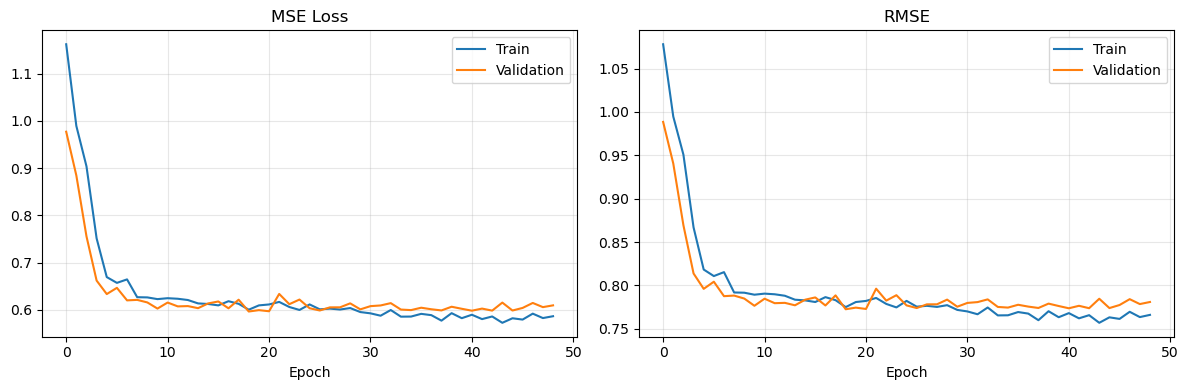

In [30]:
# Plot Training History
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='Train')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].set_title('MSE Loss')
ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(history.history['rmse'], label='Train')
ax[1].plot(history.history['val_rmse'], label='Validation')
ax[1].set_title('RMSE')
ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('training_history.png', dpi=150); plt.show()

In [31]:
# Evaluate on Test Set
best_model = keras.models.load_model('best_milk_model.keras')
y_pred_s = best_model.predict(test_ds)
y_pred   = scaler.inverse_transform(y_pred_s)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [33]:
# Metrics Per Target
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"{'Target':<10} {'RMSE':>10} {'MAE':>10} {'R²':>10}")

for i, name in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    print(f"{name:<10} {rmse:>10.4f} {mae:>10.4f} {r2:>10.4f}")

Target           RMSE        MAE         R²
Fat            0.3126     0.2490     0.8574
Prot           0.2984     0.2369     0.2714
Lact           0.1568     0.1201     0.2089


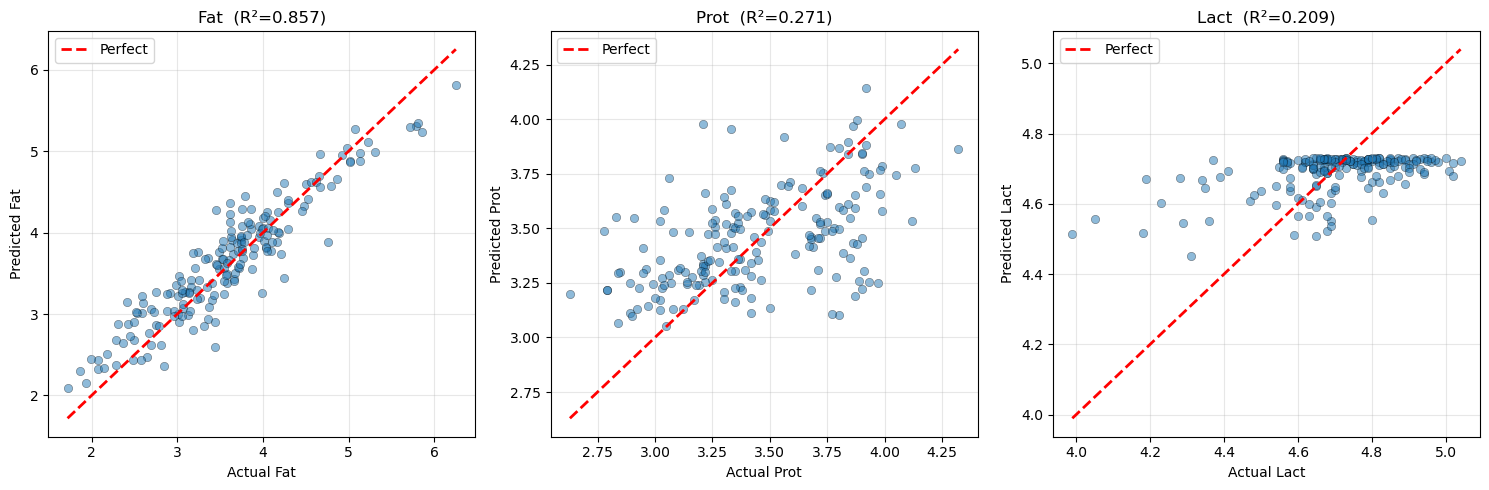

In [34]:
# Predictions vs Actual (Visual)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, name) in enumerate(zip(axes, targets)):
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.5, edgecolors='k', linewidth=0.4)
    lo = min(y_test[:, i].min(), y_pred[:, i].min())
    hi = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect')
    ax.set_xlabel(f'Actual {name}'); ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  (R²={r2_score(y_test[:, i], y_pred[:, i]):.3f})')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('predictions_vs_actual.png', dpi=150); plt.show()

In [35]:
# Save Model (for Deployment Later)
best_model.save('milk_model.keras')
print("Saved: milk_model.keras and target_scaler.pkl")

Saved: milk_model.keras and target_scaler.pkl


In [37]:
# Target	RMSE	MAE	      R²	   Interpretation
# Fat	    0.3126	0.2490	0.857	✅ Excellent — model learned it well
# Prot	0.2984	0.2369	0.271	⚠️ Weak — barely better than guessing the mean
# Lact	0.1568	0.1201	0.209	⚠️ Weak — same issue





# Why Fat works but Prot/Lact don't
# This isn't a bug. It's domain physics:

# Fat has strong, distinct absorption bands in the NIR region — it's chemically easy to detect with light.
# Protein and Lactose absorb weakly and their signals are overlapped by water (milk is 87% water). Their NIR signal is buried in noise.
# This is a well-known fact in NIR spectroscopy literature. Real published papers on this exact dataset report similar patterns





# Dataset Take from
# Dataset: https://zenodo.org/records/8263430

In [ ]:
# Stage	                    Analogy
# Jupyter notebook	        You cooking a meal in your kitchen for yourself
# Trained model file	       The recipe written down
# FastAPI	                   A restaurant counter where customers place orders
# The API endpoint	       The window where you hand over your order
# Server	                   The restaurant building
# Deployment	               The restaurant is open to the public

# Deployment means making it available to anyone, anywhere, through the internet